# Unit 5 — 05: Experiment Tracking with MLflow (and W&B Overview)

**What you will do:** Run 4 experiments with different hyperparameters, log them to MLflow, query results programmatically, load a saved model, and compare MLflow vs Weights & Biases.

**Why it matters:** Without experiment tracking, you cannot reproduce a model from 3 months ago, compare runs fairly, or explain to stakeholders why you chose a specific model.

**How to run:** Python 3.10+. `pip install mlflow scikit-learn` first. Run cells in order.

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 5, lesson 01 "01. Grid Search and Random Search" — a sweep produces dozens of runs whose settings and scores are easy to lose; MLflow is where those parameters, metrics and artifacts get written down so a run can still be found months later.

---

## 📰 A-level results, August 2020: a model nobody could interrogate in time

With exams cancelled by the pandemic, England's regulator Ofqual replaced teacher-submitted Centre Assessment Grades with grades produced by a statistical standardisation model. When A-level results were published on **13 August 2020**, roughly **40% of teacher-assessed grades had been downgraded** by one grade or more, with pupils in schools serving deprived areas disproportionately affected. Within days, following public protest and legal threats, the calculated grades were withdrawn and centre-assessed grades reinstated.

The technical detail relevant to this notebook is *when* the method became inspectable. Ofqual's technical documentation — hundreds of pages describing the model, its parameters and its evaluation — was published essentially alongside the results themselves. The model had been developed, evaluated and chosen over alternatives; but the record of that process reached the people affected only after the decision had been executed on hundreds of thousands of students.

**What goes wrong without this lesson.** Fifty models trained over two months with no tracking produces three specific inabilities: you cannot say which run made the model now in production, you cannot say what a new colleague has already tried, and you cannot answer a regulator asking what data a decision was trained on. None of those is a modelling problem. All three are record-keeping problems, and they are solved before the incident or not at all.

## Section 1 — Why Experiment Tracking

Consider a team that trains 50 models over two months without tracking:

- A model deployed in production gives wrong predictions. Which training run produced it?
- A new team member wants to beat the current model. What hyperparameters were tried?
- A regulator asks: what data was this model trained on? Nobody knows.

Experiment tracking solves all three by making every training run a first-class artifact:
- **Parameters** (what you set before training)
- **Metrics** (what you measured after training)
- **Artifacts** (the model file, plots, feature importance)
- **Tags** (dataset version, environment, team)
- **Code version** (git commit hash)

## Section 2 — MLflow Core Concepts

| Concept | Description |
|---|---|
| **Experiment** | A named group of related runs (e.g., "iris-classifier") |
| **Run** | A single training execution within an experiment |
| **Parameters** | Inputs to the run (hyperparameters, config) |
| **Metrics** | Outputs (accuracy, loss, latency) — can be logged per step |
| **Artifacts** | Files produced (model, plots, confusion matrix) |
| **Tracking URI** | Where MLflow stores data (local file, SQLite, remote server) |

## Section 3 — Set Up MLflow Tracking

In [1]:
# WHAT: point MLflow at a local SQLite backend and create the experiment.
# WHY: tracking needs a store; SQLite gives every student the full MLflow
# experience — runs, params, metrics, artifacts — without any server.
import pathlib
import mlflow
import mlflow.sklearn
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Use SQLite as a local tracking backend — no server needed
DB_PATH = pathlib.Path("/tmp/mlruns.db")
# Start from a clean store: without this, re-running the notebook appends a second
# copy of every run and the comparison table below quietly doubles.
DB_PATH.unlink(missing_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{DB_PATH}")

EXPERIMENT_NAME = "iris-classifier"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking URI: sqlite:///{DB_PATH}")
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"MLflow version: {mlflow.__version__}")

# The shared dataset all logged runs will train on.
# Load data
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nData: {len(X_train)} train, {len(X_test)} test samples")

2026/08/29 22:41:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/29 22:41:40 INFO mlflow.store.db.utils: Updating database tables


2026/08/29 22:41:40 INFO mlflow.tracking.fluent: Experiment with name 'iris-classifier' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:////tmp/mlruns.db
Experiment: iris-classifier
MLflow version: 3.13.0

Data: 120 train, 30 test samples


## Section 4 — Run 4 Experiments with Different Hyperparameters

In [2]:
# WHAT: train four different model configurations, logging params, metrics, tags,
# and the model artifact of each as an MLflow run.
# WHY: this replaces 'results.xlsx and memory' — every run becomes a queryable
# record, and the with-block guarantees runs close even if training throws.
import time
from typing import Dict, Any

# The candidates: one linear baseline and three tree ensembles to compare.
experiments = [
    {
        "run_name": "LogisticRegression_C1",
        "model": LogisticRegression(C=1.0, max_iter=200),
        "params": {"model_type": "LogisticRegression", "C": 1.0, "max_iter": 200},
    },
    {
        "run_name": "RandomForest_50",
        "model": RandomForestClassifier(n_estimators=50, random_state=42),
        "params": {"model_type": "RandomForest", "n_estimators": 50, "random_state": 42},
    },
    {
        "run_name": "RandomForest_100",
        "model": RandomForestClassifier(n_estimators=100, random_state=42),
        "params": {"model_type": "RandomForest", "n_estimators": 100, "random_state": 42},
    },
    {
        "run_name": "GradientBoosting_50",
        "model": GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=42),
        "params": {"model_type": "GradientBoosting", "n_estimators": 50, "learning_rate": 0.1},
    },
]

logged_run_ids = []

print(f"{'Run':<25} {'Accuracy':>10} {'F1 (macro)':>12} {'Time (s)':>10}")
print("-" * 62)

# One MLflow run per candidate: log inputs (params) BEFORE outputs (metrics),
# so even a crashed run records what was attempted.
for exp in experiments:
    with mlflow.start_run(run_name=exp["run_name"]) as run:
        # Log parameters
        mlflow.log_params(exp["params"])
        mlflow.set_tag("dataset", "iris")
        mlflow.set_tag("framework", "sklearn")

        # Train
        t0 = time.perf_counter()
        exp["model"].fit(X_train, y_train)
        train_time = time.perf_counter() - t0

        # Evaluate
        y_pred = exp["model"].predict(X_test)
        accuracy = float(accuracy_score(y_test, y_pred))
        f1 = float(f1_score(y_test, y_pred, average="macro"))

        # Log metrics
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("f1_macro", f1)
        mlflow.log_metric("training_time_s", round(train_time, 3))

        # Log model artifact
        mlflow.sklearn.log_model(exp["model"], artifact_path="model")

        logged_run_ids.append(run.info.run_id)
        print(f"{exp['run_name']:<25} {accuracy:>10.4f} {f1:>12.4f} {train_time:>10.3f}")

print(f"\nLogged {len(logged_run_ids)} runs to experiment '{EXPERIMENT_NAME}'.")

2026/08/29 22:41:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/29 22:41:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run                         Accuracy   F1 (macro)   Time (s)
--------------------------------------------------------------


2026/08/29 22:41:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/29 22:41:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

RandomForest_50               1.0000       1.0000      0.019


2026/08/29 22:41:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/29 22:41:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest_100              1.0000       1.0000      0.037


GradientBoosting_50           1.0000       1.0000      0.027

Logged 4 runs to experiment 'iris-classifier'.


## Section 5 — Query Results Programmatically

All runs in experiment:
  tags.mlflow.runName  metrics.accuracy  metrics.f1_macro  metrics.training_time_s  params.model_type
  GradientBoosting_50               1.0               1.0                    0.027   GradientBoosting
     RandomForest_100               1.0               1.0                    0.037       RandomForest
      RandomForest_50               1.0               1.0                    0.019       RandomForest
LogisticRegression_C1               1.0               1.0                    0.006 LogisticRegression

Best run: GradientBoosting_50
  Run ID:   36a418e1742e4715bce358f48b6269c1
  Accuracy: 1.0000


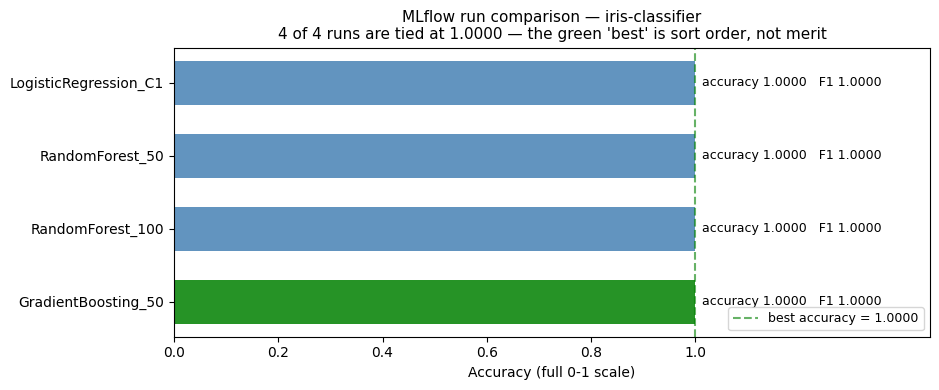

In [3]:
# WHAT: query the tracking store with search_runs(), pick the best run, and
# plot the comparison.
# WHY: this is the payoff of logging — model selection becomes a DataFrame
# query over recorded facts instead of scrolling through notebook history.
import pandas as pd
import matplotlib.pyplot as plt

# Search all runs in the experiment
runs_df = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])

# Show key columns
display_cols = ["tags.mlflow.runName", "metrics.accuracy", "metrics.f1_macro",
                "metrics.training_time_s", "params.model_type"]
print("All runs in experiment:")
print(runs_df[display_cols].to_string(index=False))

# Find the best run by accuracy
best_run = runs_df.sort_values("metrics.accuracy", ascending=False).iloc[0]
best_run_id = best_run["run_id"]
best_accuracy = best_run["metrics.accuracy"]
best_name = best_run["tags.mlflow.runName"]

print(f"\nBest run: {best_name}")
print(f"  Run ID:   {best_run_id}")
print(f"  Accuracy: {best_accuracy:.4f}")

# Green = the run the query returned as "best". The full 0-1 axis and the printed
# value on every bar are deliberate: a zoomed axis would turn a tie into a ranking.
run_names = runs_df["tags.mlflow.runName"].tolist()
accuracies = runs_df["metrics.accuracy"].tolist()
f1s = runs_df["metrics.f1_macro"].tolist()
colors = ["green" if r == best_name else "steelblue" for r in run_names]

n_tied = sum(1 for a in accuracies if abs(a - max(accuracies)) < 1e-9)

fig, ax = plt.subplots(figsize=(9.5, 4))
ypos = range(len(run_names))
bars = ax.barh(list(ypos), accuracies, color=colors, alpha=0.85, height=0.6)
for bar, acc, f1 in zip(bars, accuracies, f1s):
    ax.text(acc + 0.012, bar.get_y() + bar.get_height() / 2,
            f"accuracy {acc:.4f}   F1 {f1:.4f}", va="center", fontsize=9)
ax.set_yticks(list(ypos)); ax.set_yticklabels(run_names)
ax.axvline(max(accuracies), color="green", linestyle="--", alpha=0.6,
           label=f"best accuracy = {max(accuracies):.4f}")
ax.set_xlabel("Accuracy (full 0-1 scale)")
ax.set_xlim(0, 1.45)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
title = "MLflow run comparison — iris-classifier"
if n_tied > 1:
    title += f"\n{n_tied} of {len(run_names)} runs are tied at {max(accuracies):.4f}"
    title += " — the green 'best' is sort order, not merit"
ax.set_title(title, fontsize=11)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("/tmp/mlflow_results.png", dpi=72)
plt.show()

**Read the figure.** Four bars of identical length, four identical labels: accuracy 1.0000 and F1 1.0000 for every configuration, from a one-line logistic regression to a 100-tree forest. The green bar is green only because `sort_values(...).iloc[0]` had to return *something*; the dashed line it sits against is shared by all four. The axis runs the full 0 to 1 on purpose — zooming in to 0.8-1.01, which is the reflex when bars look similar, would have stretched a rounding-level difference into a visible ranking.

**What it proves.** The tracking store did its job and the experiment still answers nothing. A leaderboard is only informative if the metric behind it can separate the candidates, and here it cannot. Hold onto that before Section 6 — the next 'See it' finds the axis these four runs are *not* tied on.

## Section 6 — Load a Model from MLflow

In [4]:
# Load the best model back from the MLflow artifact store
model_uri = f"runs:/{best_run_id}/model"
print(f"Loading model from: {model_uri}")

loaded_model = mlflow.sklearn.load_model(model_uri)
print(f"Loaded: {type(loaded_model).__name__}")

# Verify it produces identical predictions
y_pred_loaded = loaded_model.predict(X_test)
accuracy_loaded = float(accuracy_score(y_test, y_pred_loaded))
print(f"Accuracy from loaded model: {accuracy_loaded:.4f} (matches logged: {accuracy_loaded == best_accuracy})")

# Predict a single sample
sample = X_test[0].reshape(1, -1)
prediction = loaded_model.predict(sample)[0]
proba = loaded_model.predict_proba(sample)[0]
print(f"\nSample prediction: {iris.target_names[prediction]} (confidence: {proba.max():.3f})")

Loading model from: runs:/36a418e1742e4715bce358f48b6269c1/model


Loaded: GradientBoostingClassifier
Accuracy from loaded model: 1.0000 (matches logged: True)

Sample prediction: versicolor (confidence: 0.994)


## 👁️ See it — the metric that ties, and the curve that flattens

The run table has a problem you can see faster than you can read: four rows, four identical accuracies. Two pictures make the situation legible.

The first uses a feature of MLflow the table above never exercised — **metrics logged per step**. A gradient-boosting model is built one tree at a time, so it has 50 intermediate states, and `mlflow.log_metric(..., step=i)` records every one of them inside the run that already exists. Then we read the curve **back out of the tracking store** with `MlflowClient.get_metric_history` and plot it, which is exactly what a dashboard does.

Read back 50 logged steps from run 36a418e1...


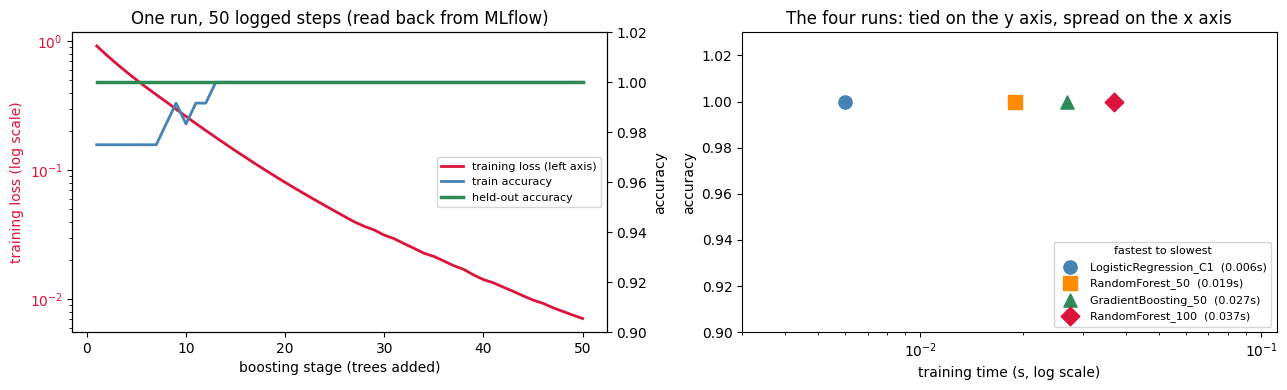

training loss:    stage 1 = 0.9204  ->  stage 50 = 0.00710 (130x lower)
held-out accuracy: stage 1 = 1.0000  ->  stage 50 = 1.0000
training time spread across the four runs: 0.006s to 0.037s (6x)


In [5]:
# WHAT: log the 50 boosting stages of the GradientBoosting run as stepped metrics,
# read them back out of the tracking store, and plot them next to the run table.
# WHY: a per-step metric is the difference between "the model scored 1.0" and
# "the model scored 1.0 after one tree and we trained 49 more" — and the point of
# a tracking store is that the curve is still there after the notebook is closed.
from mlflow.tracking import MlflowClient

# Resume the run that already exists — no fifth run, no new experiment.
gb_run_id = runs_df.loc[runs_df["tags.mlflow.runName"] == "GradientBoosting_50",
                        "run_id"].iloc[0]

gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
# staged_predict replays the ensemble after 1, 2, ... 50 trees.
train_acc_by_stage = [accuracy_score(y_train, p) for p in gb.staged_predict(X_train)]
test_acc_by_stage  = [accuracy_score(y_test,  p) for p in gb.staged_predict(X_test)]
train_loss_by_stage = [float(v) for v in gb.train_score_]   # training loss per stage

with mlflow.start_run(run_id=gb_run_id):
    for step, (loss, tr_acc, te_acc) in enumerate(
            zip(train_loss_by_stage, train_acc_by_stage, test_acc_by_stage), start=1):
        mlflow.log_metric("train_loss_by_stage", loss, step=step)
        mlflow.log_metric("train_accuracy_by_stage", tr_acc, step=step)
        mlflow.log_metric("test_accuracy_by_stage", te_acc, step=step)

# Read the curves back from the store — this is the query a dashboard runs.
client = MlflowClient()
def metric_series(name):
    history = sorted(client.get_metric_history(gb_run_id, name), key=lambda m: m.step)
    return [m.step for m in history], [m.value for m in history]

steps, loss_curve = metric_series("train_loss_by_stage")
_, train_curve = metric_series("train_accuracy_by_stage")
_, test_curve = metric_series("test_accuracy_by_stage")
print(f"Read back {len(steps)} logged steps from run {gb_run_id[:8]}...")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax_loss = axes[0]
ax_loss.plot(steps, loss_curve, color="crimson", lw=2, label="training loss (left axis)")
ax_loss.set_yscale("log")
ax_loss.set_xlabel("boosting stage (trees added)")
ax_loss.set_ylabel("training loss (log scale)", color="crimson")
ax_loss.tick_params(axis="y", labelcolor="crimson")
ax_acc = ax_loss.twinx()
ax_acc.plot(steps, train_curve, color="steelblue", lw=2, label="train accuracy")
ax_acc.plot(steps, test_curve, color="seagreen", lw=2.5, label="held-out accuracy")
ax_acc.set_ylabel("accuracy"); ax_acc.set_ylim(0.9, 1.02)
lines = ax_loss.get_lines() + ax_acc.get_lines()
ax_acc.legend(lines, [l.get_label() for l in lines], fontsize=8, loc="center right")
ax_loss.set_title("One run, 50 logged steps (read back from MLflow)")

ax_cmp = axes[1]
times = runs_df["metrics.training_time_s"].tolist()
accs = runs_df["metrics.accuracy"].tolist()
names = runs_df["tags.mlflow.runName"].tolist()
# One scatter call per run so the names go in the legend: three of the four runs
# sit so close together in time that annotations would overlap.
markers = ["o", "s", "^", "D"]
colours = ["steelblue", "darkorange", "seagreen", "crimson"]
for k, idx in enumerate(np.argsort(times)):
    ax_cmp.scatter(times[idx], accs[idx], s=90, marker=markers[k % 4],
                   color=colours[k % 4], label=f"{names[idx]}  ({times[idx]:.3f}s)")
ax_cmp.legend(fontsize=8, loc="lower right", title="fastest to slowest", title_fontsize=8)
ax_cmp.set_xscale("log")
ax_cmp.set_xlim(min(times) * 0.5, max(times) * 3)
ax_cmp.set_ylim(0.9, 1.03)
ax_cmp.set_xlabel("training time (s, log scale)")
ax_cmp.set_ylabel("accuracy")
ax_cmp.set_title("The four runs: tied on the y axis, spread on the x axis")

plt.tight_layout()
plt.savefig("/tmp/mlflow_stepped_metrics.png", dpi=72)
plt.show()

print(f"training loss:    stage 1 = {loss_curve[0]:.4f}  ->  stage {steps[-1]} = {loss_curve[-1]:.5f} "
      f"({loss_curve[0] / loss_curve[-1]:.0f}x lower)")
print(f"held-out accuracy: stage 1 = {test_curve[0]:.4f}  ->  stage {steps[-1]} = {test_curve[-1]:.4f}")
print(f"training time spread across the four runs: "
      f"{min(times):.3f}s to {max(times):.3f}s ({max(times) / min(times):.0f}x)")

**Read the left panel.** The red curve is the training loss and it falls by more than two orders of magnitude across the 50 boosting stages — on a log axis it looks like steady, convincing progress. The green curve is accuracy on data the model never saw, and it is a **flat line at 1.000 from stage 1**. The blue train-accuracy line starts lower, steps up over stages 8-13 and is pinned at 1.000 from there on — the model finishing off the last few *training* rows. Forty-nine of the fifty trees bought no generalisation at all; they bought a smaller number in the loss column.

**Read the right panel.** All four runs sit on the same horizontal line — that is the tie, drawn. The only axis on which they differ is time, and it is a log axis: the logistic regression trains several times faster than the ensembles (the legend lists the four training times fastest-to-slowest; because these are wall-clock seconds the exact factor moves every time the notebook runs). If the metric you optimised cannot separate your candidates, the deciding evidence has to come from a column you were not looking at.

**What it proves.** Tracking did its job perfectly and the experiment is still uninformative. A tracking store records what happened; it cannot tell you that your evaluation is too easy to distinguish a logistic regression from a boosted ensemble. **A perfect score is a signal to change the evaluation, not to declare a winner** — and the step-wise curve is the cheapest evidence that the extra capacity you paid for is not doing anything.

## 💬 Discuss

Look carefully at the run table. **All four configurations scored accuracy 1.0 and F1 1.0** — LogisticRegression, two RandomForests and GradientBoosting. The "best run" the query selected, `GradientBoosting_50`, won a four-way tie by sort order, not by merit. The only column that actually separates them is training time — read the four wall-clock values in the run table above, where the logistic regression trains several times faster than any of the ensembles.

1. Given a perfect tie on the metric you optimised, what would you promote and why? Rank the four using something the table *does* contain, then name the two columns you wish had been logged.
2. `search_runs()` sorts by accuracy and takes the top row. That is how a lot of real model selection works. What would you change so the query cannot silently return an arbitrary winner? (Consider what a tie should *do*.)
3. Under the Ofqual case above: if a student asked why they received a particular grade, which fields in these MLflow runs would help, and which questions would remain unanswerable no matter how complete the tracking? Where is the boundary between reproducibility and explainability?

## Section 7 — Weights & Biases Overview

W&B is a cloud-hosted experiment tracking platform. The API is similar to MLflow but it offers richer real-time dashboards and team collaboration features.

**Note:** W&B requires an API key (`wandb login`). The code below shows the pattern — run it only if you have a W&B account.

In [6]:
# W&B equivalent of the MLflow experiment above
# Requires: pip install wandb && wandb login
try:
    import wandb

    # Initialize a run
    wandb.init(
        project="iris-classifier",
        name="RandomForest_100",
        config={"n_estimators": 100, "random_state": 42},  # params
    )

    # Log metrics (can be called per epoch/step for deep learning)
    wandb.log({"accuracy": 0.9667, "f1_macro": 0.9667, "training_time_s": 0.08})

    # Save an artifact
    # artifact = wandb.Artifact("iris-model", type="model")
    # artifact.add_file("/tmp/model.pkl")
    # wandb.log_artifact(artifact)

    wandb.finish()
    print("W&B run logged successfully.")

except ImportError:
    print("W&B not installed (pip install wandb). Showing code pattern above.")
except Exception as e:
    print(f"W&B error (likely not logged in): {e}")

print("""
MLflow vs Weights & Biases comparison:

| Feature              | MLflow                    | W&B                        |
|----------------------|---------------------------|----------------------------|
| Hosting              | Self-hosted or Databricks | Cloud (wandb.ai)           |
| Cost                 | Open-source, free         | Free tier, paid for teams  |
| Setup                | pip install mlflow        | pip install wandb + login  |
| Real-time dashboards | Limited                   | Excellent                  |
| Team collaboration   | Via shared server         | Built-in                   |
| Hyperparameter sweep | Manual                    | wandb.sweep() built-in     |
| Data privacy         | Full control              | Cloud (data leaves machine)|
| Best for             | On-prem, regulated envs   | Research, fast iteration   |
""")

W&B not installed (pip install wandb). Showing code pattern above.

MLflow vs Weights & Biases comparison:

| Feature              | MLflow                    | W&B                        |
|----------------------|---------------------------|----------------------------|
| Hosting              | Self-hosted or Databricks | Cloud (wandb.ai)           |
| Cost                 | Open-source, free         | Free tier, paid for teams  |
| Setup                | pip install mlflow        | pip install wandb + login  |
| Real-time dashboards | Limited                   | Excellent                  |
| Team collaboration   | Via shared server         | Built-in                   |
| Hyperparameter sweep | Manual                    | wandb.sweep() built-in     |
| Data privacy         | Full control              | Cloud (data leaves machine)|
| Best for             | On-prem, regulated envs   | Research, fast iteration   |



## Summary

What experiment tracking solves:
- **Reproducibility** — every run is logged with parameters, metrics, and the exact model artifact
- **Comparison** — `mlflow.search_runs()` lets you query and rank all experiments programmatically
- **Auditability** — you can always answer "which run produced the model currently in production?"
- **Rollback** — you can load any previous model artifact in one line

MLflow vs W&B: use MLflow when you need on-premises control or are in a regulated environment; use W&B when you want rich dashboards and team features with minimal setup.

## Self-Check (answer before scrolling back up)

1. **What is the difference between an MLflow 'experiment' and a 'run'?**  
   An experiment is a named container for related runs — like a project folder. A run is a single execution within that experiment — like one training job. You can have hundreds of runs inside one experiment.

2. **How do you load a specific model version from MLflow?**  
   Use `mlflow.sklearn.load_model(f"runs:/{run_id}/model")`. You need the `run_id`, which you can find by querying `mlflow.search_runs()` and filtering or sorting by metric.

3. **When would you prefer W&B over MLflow?**  
   When you need real-time training dashboards (especially for deep learning with per-epoch metrics), when your team collaborates remotely and needs shared experiment views, or when you want the built-in hyperparameter sweep feature (`wandb.sweep`). For on-premises data requirements or regulated industries, MLflow's self-hosted option is safer.

## ⚠️ Where this breaks

- **Tracking records what happened; it does not make what happened good.** All four runs here scored 1.0, which tells you the dataset is too easy, not that the models are excellent. A tracking system will faithfully store fifty runs of a badly-specified experiment and present a leaderboard of noise. **A tie or a suspiciously perfect score is a signal to change the evaluation, not to pick a winner.**
- **Logged metrics are only as trustworthy as the split behind them.** MLflow stores the number you give it. It has no idea whether your test set leaked into training, whether the split was stratified, or whether the same split was used for every run. Log the split definition — or better, a hash of the exact rows — alongside the metric.
- **Auto-logged model artifacts inherit the pickle problem.** The cell above emits scikit-learn's own warning: saving in pickle/cloudpickle format relies on Python object serialization that *can execute arbitrary code during deserialization*, with `skops` suggested as the safer alternative. A model registry is a place where artifacts from many people accumulate, which makes it exactly the place that property matters (Unit 1, notebook 02).
- **The assumption that must hold:** the tracking store outlives the project and stays readable. `sqlite:////tmp/mlruns.db` is in `/tmp`. On a shared machine or a CI runner it is gone on reboot, taking the entire audit trail with it. Point the tracking URI at durable storage from the first run, not from the first incident.
- **Tracking runs is not tracking deployments.** MLflow can tell you which run produced an artifact. It cannot tell you which artifact was *live* at 14:32 on the day of the complaint unless your deployment writes that back (Unit 2, notebook 03 and Unit 5, notebook 06 supply the missing half).
- **The cheaper alternative.** For a single person running a handful of experiments, a CSV of parameters and metrics plus the artifact filenames is honest and takes five minutes. MLflow earns its setup cost when several people run experiments, when runs must be compared months apart, or when someone external will ask questions about provenance.

## 🔭 State of the field (2026)

MLflow is still the answer to "where do the runs go", and nothing below changes that. What changed is the
standard for what a logged run has to contain before anyone is allowed to believe it — and this notebook's
four-way tie at accuracy 1.0000 is the canonical example of a faithfully tracked, uninformative result.
Two 2025–26 lines of work attack it. Lee et al. (2025, arXiv:2511.21140) give the statistics for reporting
model-graded evaluations properly, constructing confidence intervals that account for uncertainty in both
the test and calibration sets instead of quoting a single score. Ghosh et al. (2026, arXiv:2606.09809)
propose **Evaluation Cards**, a standard interpretive record of how a result was produced, applied across
thousands of models and benchmarks to locate exactly where reporting is missing.

The practical translation for your `mlflow.log_metric()` calls is short: log repeated runs and an interval
rather than one number, log the split definition beside the score, and ship the card with the model. All
three are additions to the tracking discipline taught here, not substitutes for it — parameters, metrics,
artifacts and a queryable store are the substrate those standards are written on top of, and they are what
the official plan examines.

## 📚 References

1. Zaharia, M., Chen, A., Davidson, A., et al. (2018). *Accelerating the Machine Learning Lifecycle with MLflow*. IEEE Data Engineering Bulletin 41(4).
2. Pineau, J., Vincent-Lamarre, P., Sinha, K., et al. (2021). *Improving Reproducibility in Machine Learning Research (A Report from the NeurIPS 2019 Reproducibility Program)*. JMLR 22. <https://arxiv.org/abs/2003.12206>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2022). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access. <https://arxiv.org/abs/2205.02302>
4. Lee, C., Zeng, T., Jeong, J., Sohn, J.-y., & Lee, K. (2025). *How to Correctly Report LLM-as-a-Judge Evaluations*. arXiv:2511.21140. <https://arxiv.org/abs/2511.21140>
5. Ghosh, A., Reuel, A., Chim, J., et al. (2026). *Evaluation Cards: An Interpretive Layer for AI Evaluation Reporting*. arXiv:2606.09809. <https://arxiv.org/abs/2606.09809>
